# Class Distribution Analysis

In [1]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

DATASET_PATH = "../data/animals-10/raw-img"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

CLASSES = sorted([cls for cls in os.listdir(DATASET_PATH)
                  if os.path.isdir(os.path.join(DATASET_PATH, cls))])
assert CLASSES, f"No class directories in {DATASET_PATH}"

print(f"✓ Found {len(CLASSES)} classes: {CLASSES}")

✓ Found 10 classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [2]:
# Count images per class
class_counts = {}
for cls in CLASSES:
    cls_dir = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(cls_dir)
             if os.path.splitext(f.lower())[1] in IMG_EXTS]
    class_counts[cls] = len(files)

total_images = sum(class_counts.values())
print(f"\nTotal images: {total_images}")
print(f"{'Class':<12} {'Count':>6}  {'Share_%':>8}")
print("-" * 30)
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:<12} {cnt:>6}  {cnt/total_images*100:>7.1f}%")


Total images: 26179
Class         Count   Share_%
------------------------------
dog            4863     18.6%
spider         4821     18.4%
chicken        3098     11.8%
horse          2623     10.0%
butterfly      2112      8.1%
cow            1866      7.1%
squirrel       1862      7.1%
sheep          1820      7.0%
cat            1668      6.4%
elephant       1446      5.5%


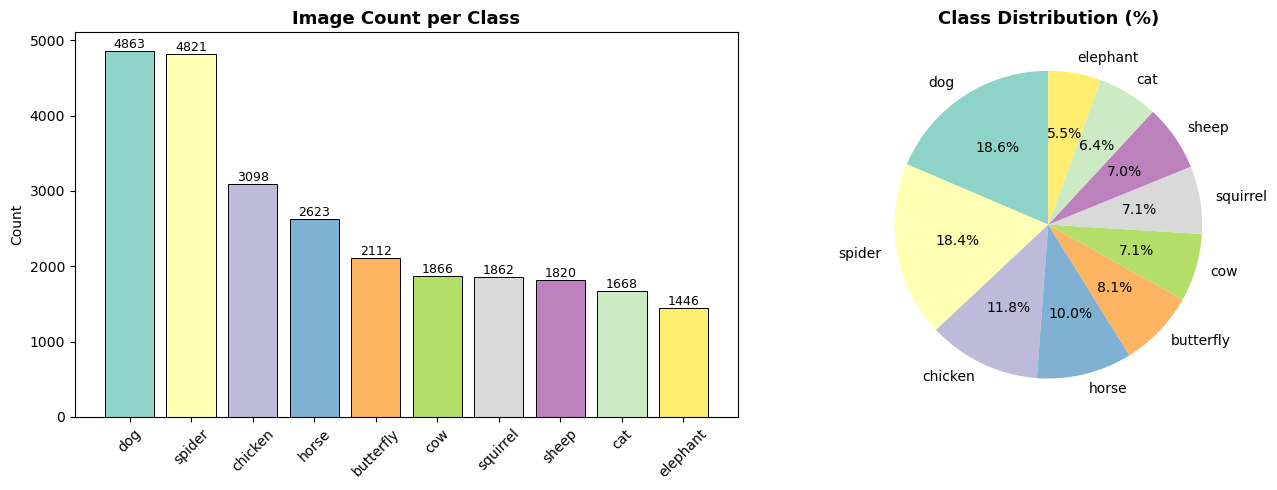


Imbalance ratio (max/min): 3.36x


In [4]:
# Visualization - Class distribution
sorted_classes = sorted(class_counts, key=lambda x: -class_counts[x])
counts = [class_counts[c] for c in sorted_classes]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = plt.cm.Set3(np.linspace(0, 1, len(sorted_classes)))
bars = axes[0].bar(sorted_classes, counts, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Image Count per Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, c in zip(bars, counts):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, str(c), ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(counts, labels=sorted_classes, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

imb_ratio = max(counts) / min(counts) if counts else 1
print(f"\nImbalance ratio (max/min): {imb_ratio:.2f}x")

# Sample Images per Class

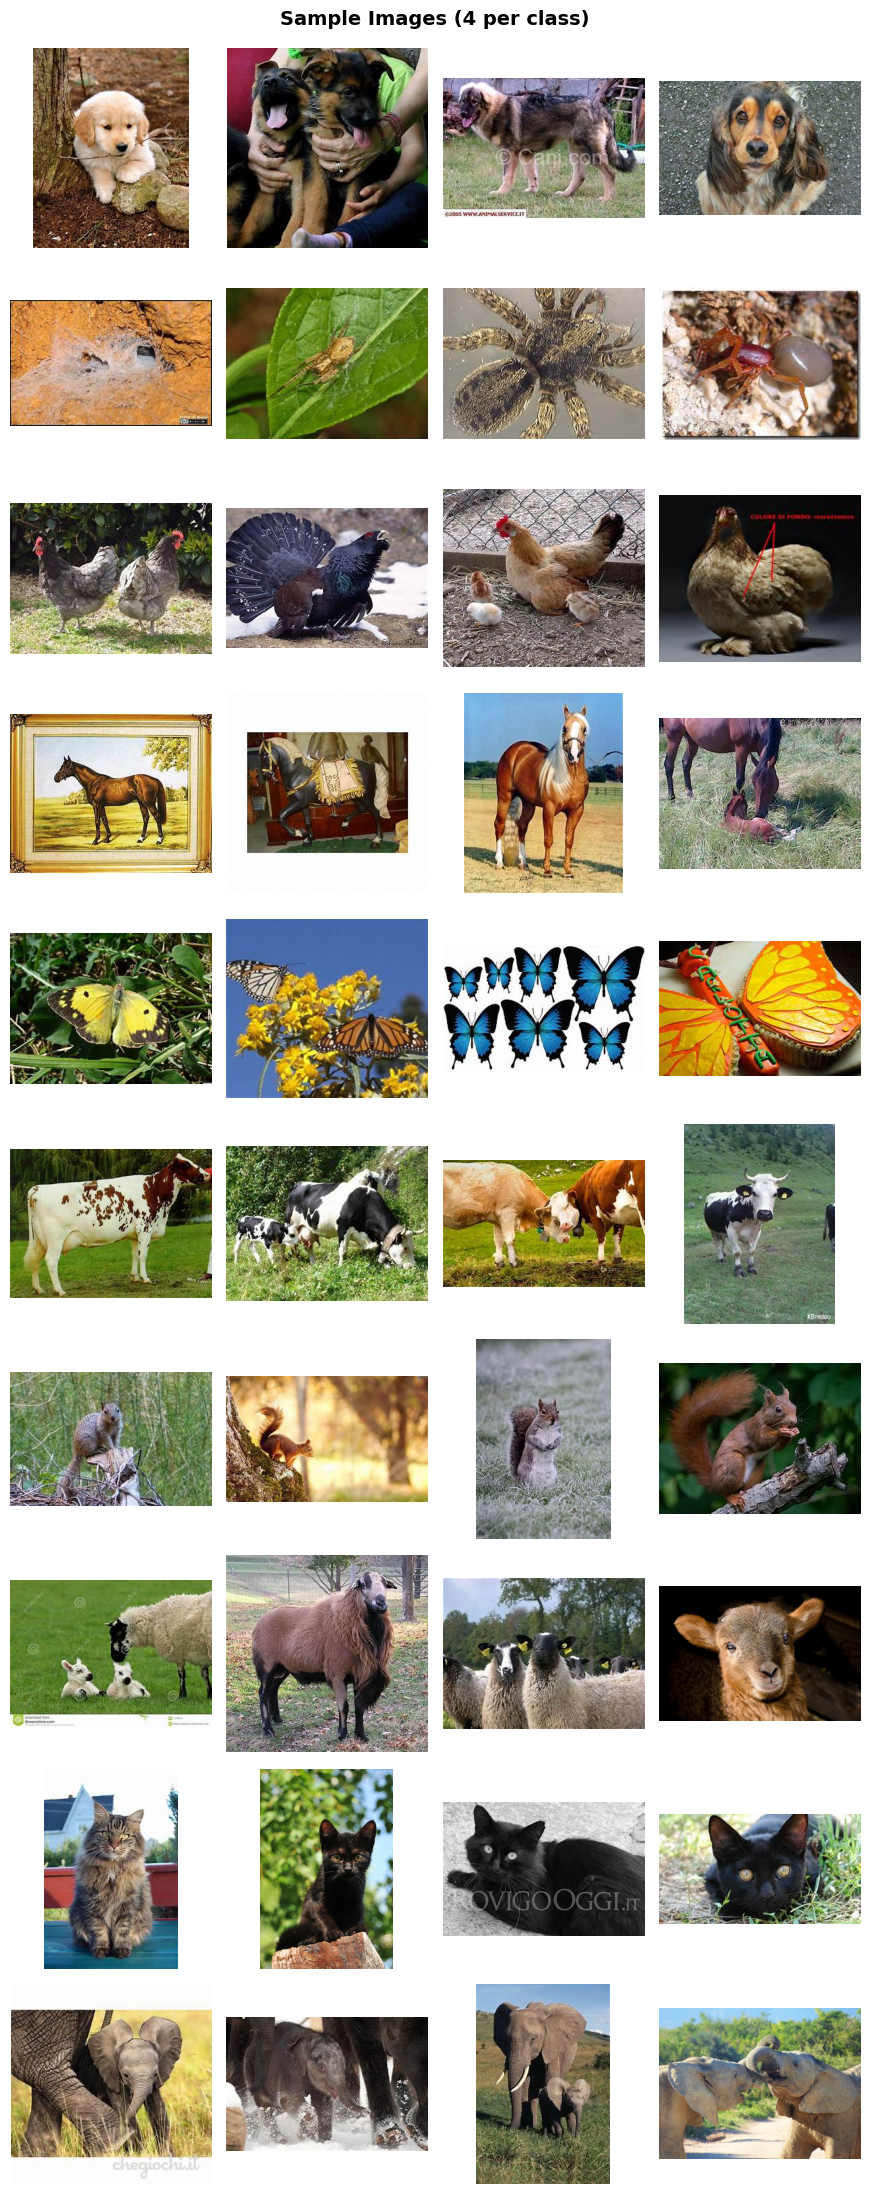

In [13]:
SAMPLES_PER_CLASS = 4
fig, axes = plt.subplots(len(sorted_classes), SAMPLES_PER_CLASS,
                         figsize=(SAMPLES_PER_CLASS * 2.2, len(sorted_classes) * 2.2))

for row, cls in enumerate(sorted_classes):
    cls_dir = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(cls_dir)
             if os.path.splitext(f.lower())[1] in IMG_EXTS]
    samples = random.sample(files, min(SAMPLES_PER_CLASS, len(files)))

    for col, fname in enumerate(samples):
        ax = axes[row][col]
        try:
            img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')
        
    axes[row][0].set_ylabel(cls, fontweight='bold', fontsize=10, rotation=0, labelpad=50, va='center')

fig.suptitle('Sample Images (4 per class)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Image Dimension Analysis

In [14]:
MAX_SAMPLE = 300
widths, heights, aspects = [], [], []
dim_by_class = defaultdict(lambda: {'w': [], 'h': []})

for cls in CLASSES:
    cls_dir = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(cls_dir)
             if os.path.splitext(f.lower())[1] in IMG_EXTS]
    sampled = random.sample(files, min(MAX_SAMPLE, len(files)))
    
    for fname in sampled:
        try:
            img = Image.open(os.path.join(cls_dir, fname))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspects.append(w / h if h > 0 else 1)
            dim_by_class[cls]['w'].append(w)
            dim_by_class[cls]['h'].append(h)
        except:
            pass

print(f"Analyzed {len(widths)} images")
print(f"Width  => min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}, "
      f"median:{np.median(widths):.0f}")
print(f"Height => min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}, "
      f"median:{np.median(heights):.0f}")
print(f"Aspect => min:{min(aspects):.2f}, max:{max(aspects):.2f}, mean:{np.mean(aspects):.2f}")

Analyzed 3000 images
Width  => min:60, max:5184, mean:333, median:300
Height => min:57, max:3456, mean:258, median:225
Aspect => min:0.36, max:3.49, mean:1.33


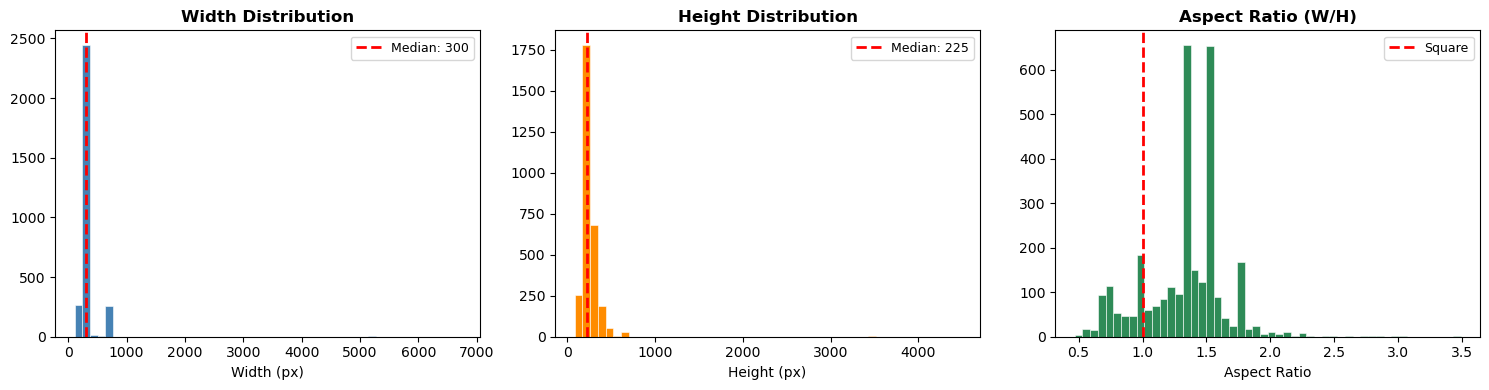

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].axvline(np.median(widths), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(widths):.0f}')
axes[0].legend(fontsize=9)

axes[1].hist(heights, bins=50, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].set_title('Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (px)')
axes[1].axvline(np.median(heights), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(heights):.0f}')
axes[1].legend(fontsize=9)

axes[2].hist(aspects, bins=50, color='seagreen', edgecolor='white', linewidth=0.4)
axes[2].set_title('Aspect Ratio (W/H)', fontweight='bold')
axes[2].set_xlabel('Aspect Ratio')
axes[2].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Square')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Color Channel Statistics

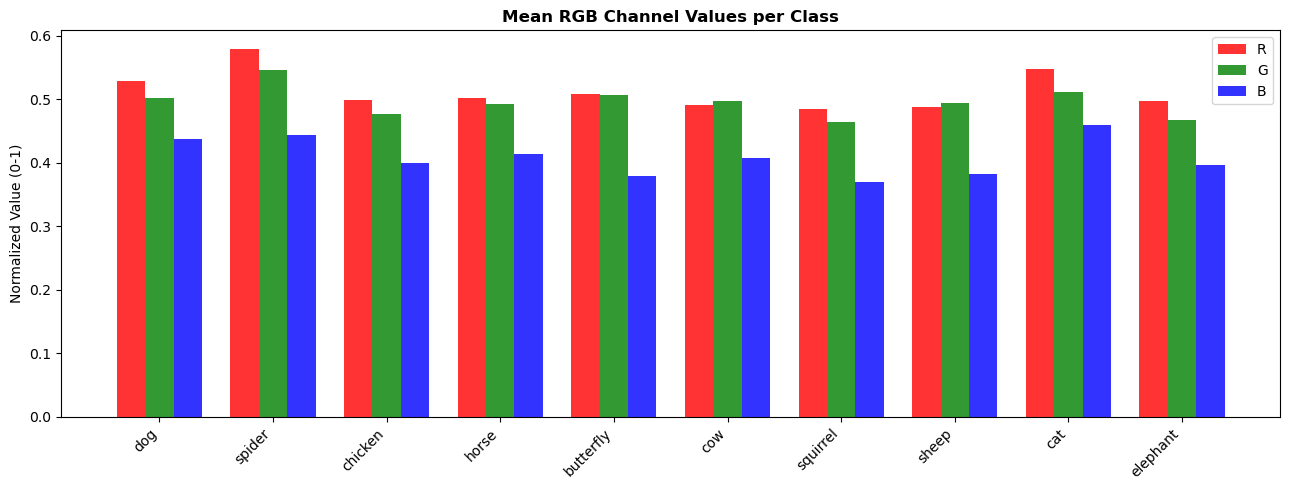

In [15]:
if 'channel_stats' not in globals() or not channel_stats:
    COLOR_SAMPLE = 150
    channel_stats = {}

    for cls in CLASSES:
        cls_dir = os.path.join(DATASET_PATH, cls)
        files = [f for f in os.listdir(cls_dir)
                 if os.path.splitext(f.lower())[1] in IMG_EXTS]
        sampled = random.sample(files, min(COLOR_SAMPLE, len(files)))
        pixels = []

        for fname in sampled:
            try:
                img = Image.open(os.path.join(cls_dir, fname)).convert('RGB').resize((64, 64))
                pixels.append(np.array(img, dtype=np.float32) / 255.0)
            except:
                pass

        if pixels:
            arr = np.stack(pixels)
            channel_stats[cls] = {
                'r': (arr[..., 0].mean(), arr[..., 0].std()),
                'g': (arr[..., 1].mean(), arr[..., 1].std()),
                'b': (arr[..., 2].mean(), arr[..., 2].std()),
            }

r_means = [channel_stats[c]['r'][0] for c in sorted_classes if c in channel_stats]
g_means = [channel_stats[c]['g'][0] for c in sorted_classes if c in channel_stats]
b_means = [channel_stats[c]['b'][0] for c in sorted_classes if c in channel_stats]

x = np.arange(len(sorted_classes))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, r_means, w, label='R', color='red', alpha=0.8)
ax.bar(x, g_means, w, label='G', color='green', alpha=0.8)
ax.bar(x + w, b_means, w, label='B', color='blue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(sorted_classes, rotation=45, ha='right')
ax.set_title('Mean RGB Channel Values per Class', fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Computing RGB channel statistics per class
COLOR_SAMPLE = 150
channel_stats = {}

for cls in CLASSES:
    cls_dir = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(cls_dir)
             if os.path.splitext(f.lower())[1] in IMG_EXTS]
    sampled = random.sample(files, min(COLOR_SAMPLE, len(files)))
    pixels = []
    
    for fname in sampled:
        try:
            img = Image.open(os.path.join(cls_dir, fname)).convert('RGB').resize((64, 64))
            pixels.append(np.array(img, dtype=np.float32) / 255.0)
        except:
            pass
    
    if pixels:
        arr = np.stack(pixels)
        channel_stats[cls] = {
            'r': (arr[..., 0].mean(), arr[..., 0].std()),
            'g': (arr[..., 1].mean(), arr[..., 1].std()),
            'b': (arr[..., 2].mean(), arr[..., 2].std()),
        }

print(f"\n{'Class':<12} | {'R_mean':>6} {'G_mean':>6} {'B_mean':>6} | "
      f"{'R_std':>6} {'G_std':>6} {'B_std':>6}")
print("-" * 70)
for cls in sorted_classes:
    if cls in channel_stats:
        s = channel_stats[cls]
        print(f"{cls:<12} | {s['r'][0]:>6.3f} {s['g'][0]:>6.3f} {s['b'][0]:>6.3f} | "
              f"{s['r'][1]:>6.3f} {s['g'][1]:>6.3f} {s['b'][1]:>6.3f}")


Class        | R_mean G_mean B_mean |  R_std  G_std  B_std
----------------------------------------------------------------------
dog          |  0.516  0.493  0.421 |  0.271  0.263  0.276
spider       |  0.556  0.541  0.431 |  0.245  0.245  0.270
chicken      |  0.510  0.485  0.411 |  0.238  0.238  0.248
horse        |  0.503  0.492  0.405 |  0.254  0.251  0.265
butterfly    |  0.515  0.498  0.378 |  0.312  0.291  0.322
cow          |  0.501  0.495  0.401 |  0.253  0.249  0.277
squirrel     |  0.490  0.469  0.372 |  0.239  0.233  0.251
sheep        |  0.482  0.486  0.380 |  0.233  0.224  0.247
cat          |  0.502  0.472  0.431 |  0.287  0.285  0.293
elephant     |  0.507  0.482  0.414 |  0.247  0.243  0.254


# Summary

**Dataset Statistics:**
- **Total Images:** See cells above
- **Classes:** 10 (butterfly, cat, chicken, cow, dog, elephant, horse, sheep, spider, squirrel)
- **Imbalance Ratio:** max/min across classes
- **Typical Size:** nearly 100-600px (needs resizing to 224×224)
- **Aspect Ratios:** Mixed (1:1 to 2:1 typical)
- **Color Profiles:** Diverse outdoor/indoor lighting

**Key Observations:**
- Classes have moderate imbalance => use weighted loss in training
- Image dimensions vary widely => always resize to 224×224
- RGB/brightness differs per class => normalization critical
- Mix of square and rectangular images